# Step 2a — Percentage drop-off filter (value sweep)

A multi-value companion to `02a_filter_pct_dropoff.ipynb`. That notebook ran the percentage drop-off rule at Dr. Miller's single suggested figure (`DROP_PCT = 0.10`); here we sweep three drop thresholds — **0.03, 0.05, 0.10** — over the *same* sample-scale walks and compare them side by side, so the choice of drop percentage is validated rather than assumed.

The core mechanics are reused **exactly** from the single-value notebook: `anchor_sorted_sims` (self excluded, never truncated), the `pct_dropoff_theta` cliff search over the top `SEARCH_WINDOW` ranks, and `filter_walk`. The *only* thing that changes across the sweep is the drop percentage the cliff search tests against.

**Efficiency.** The expensive step is ranking the whole catalogue against each anchor (one matrix-vector product plus a sort, ~20k times). That ranking does **not** depend on `DROP_PCT`, so we compute it **once per anchor** and rerun only the cheap cliff-search over it for each of the three values — the matvec+sort never runs three times.

**Reuse of the existing 0.10 run.** `outputs/filters/pct_dropoff/drop_0.10/` already exists from the single-value notebook. If it is present we **skip recomputing 0.10 entirely** and read its four artifacts back as-is for the comparisons below; only 0.03 and 0.05 are computed fresh.

**Inputs** (in `outputs/`, sample scale — the untouched `walk_raw_paths.jsonl` at the `outputs/` root, **not** `outputs/full_scale/`)
- `walk_raw_paths.jsonl`, `walk_config.json`, `product_basket_freq.json`
- `step1/embeddings.npy` + `step1/product_id_to_index.json` (+ `step1/products_text.csv`)

**Outputs**
- `filters/pct_dropoff/drop_{0.03,0.05,0.10}/` — per value: `thresholds.json`, `walk_sentences.jsonl`, `filter_config.json`, `walk_sentences_readable.txt` (0.10 reused as-is if already present)
- `filters/pct_dropoff/summary.json` — the cross-value comparison table

## 1. Imports and paths

Paths are resolved relative to the project root so the notebook works regardless of where Jupyter is launched from.

In [1]:
import json
import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
STEP1_DIR = OUT_DIR / "step1"

print("Data dir:   ", DATA_DIR)
print("Outputs dir:", OUT_DIR)

Data dir:    /Users/linnhtet/Developer/bachelor-thesis/data
Outputs dir: /Users/linnhtet/Developer/bachelor-thesis/outputs


## 2. Parameters — the swept values

The sweep is defined by `DROP_PCT_VALUES`; everything else (`SEARCH_WINDOW`, `min_sentence_length`, the fixed baseline) is held identical to the single-value notebook so the only moving part is the drop percentage. For each value we resolve its `filters/pct_dropoff/drop_{value:.2f}/` folder and check whether it already exists — if so it is reused, not recomputed.

In [2]:
METHOD_NAME = "pct_dropoff"

# ---- The sweep ----
DROP_PCT_VALUES = [0.03, 0.05, 0.10]   # relative single-step drop marking the cliff
SEARCH_WINDOW = 50                     # how deep the cliff search looks (bounds search, NOT
                                       # the ranking, which is never truncated) — held fixed

min_sentence_length = 2                # discard sentences shorter than this (same as siblings)
CONSTANT_THETA_BASELINE = 0.70         # the fixed baseline the adaptive rule is compared against

METHOD_ROOT = OUT_DIR / "filters" / METHOD_NAME
METHOD_ROOT.mkdir(parents=True, exist_ok=True)

# Resolve one config per swept value: its label, its folder, and whether that
# folder already exists (reuse-as-is) or must be computed fresh.
def value_label(v):
    return f"drop_{v:.2f}"

SWEEP = []
for v in DROP_PCT_VALUES:
    label = value_label(v)
    d = METHOD_ROOT / label
    present = (d / "thresholds.json").exists() and (d / "walk_sentences.jsonl").exists()
    SWEEP.append({"value": v, "label": label, "dir": d, "reuse": present})

VALUES_TO_COMPUTE = [c["value"] for c in SWEEP if not c["reuse"]]

print(f"{'value':>8}  {'folder':<40}  status")
print("-" * 62)
for c in SWEEP:
    print(f"{c['value']:>8.2f}  {c['label']:<40}  "
          f"{'reuse existing' if c['reuse'] else 'compute fresh'}")
print(f"\nvalues to compute fresh: {VALUES_TO_COMPUTE or '(none — all already present)'}")

   value  folder                                    status
--------------------------------------------------------------
    0.03  drop_0.03                                 compute fresh
    0.05  drop_0.05                                 compute fresh
    0.10  drop_0.10                                 reuse existing

values to compute fresh: [0.03, 0.05]


In [3]:
# Stress-test anchors — must match those 02_semantic_walk.ipynb always walked.
STRESS_TEST_IDS = {
    4210:  "Whole Milk",
    6347:  "Unsweetened Almond Milk",
    651:   "Organic Salted Butter",
    16268: "Vegan Butter",
    6104:  "Whole Milk Plain Yogurt",
    920:   "Coconut Yogurt",
}

## 3. Load the raw walks and supporting artifacts

Identical loading to the single-value notebook: raw walks + walk config from `02_semantic_walk.ipynb`, the per-product basket counts, and Step 1's embeddings + id map (used both to compute thresholds and for the rank-novelty test).

In [4]:
# Raw walks from the walk notebook (one JSON object per line).
raw_walks = []
with open(OUT_DIR / "walk_raw_paths.jsonl") as f:
    for line in f:
        raw_walks.append(json.loads(line))

# The walk run this filter is built on — its timestamp is recorded for traceability.
with open(OUT_DIR / "walk_config.json") as f:
    walk_config = json.load(f)

# Per-product sampled-basket counts (for the background popularity check).
with open(OUT_DIR / "product_basket_freq.json") as f:
    freq = json.load(f)
total_baskets = freq["total_baskets"]
product_basket_count = {int(pid): c for pid, c in freq["product_basket_count"].items()}

# Step 1 artifacts: embeddings (unit-normalised) + id map for both the threshold
# computation and the rank novelty test, and product names for readable output.
embeddings = np.load(STEP1_DIR / "embeddings.npy").astype(np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / np.clip(norms, 1e-12, None)

with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(pid): row for pid, row in json.load(f).items()}

products_text = pd.read_csv(STEP1_DIR / "products_text.csv")
id_to_name = dict(zip(products_text["product_id"], products_text["product_name"]))


def name(pid):
    return id_to_name.get(int(pid), f"?{pid}")


def names(ids):
    return [name(p) for p in ids]


print(f"raw walks loaded      : {len(raw_walks):,}")
print(f"walk_config timestamp : {walk_config.get('timestamp')}")
print(f"basket counts         : {len(product_basket_count):,} products, "
      f"{total_baskets:,} total baskets")
print(f"embeddings            : {embeddings.shape}")

raw walks loaded      : 400,100
walk_config timestamp : 2026-08-08T14:06:21
basket counts         : 48,526 products, 1,000,000 total baskets
embeddings            : (49688, 384)


## 4. Rank each anchor once, sweep the cliff search over it

`anchor_sorted_sims` and `pct_dropoff_theta` are the single-value notebook's functions verbatim, except `pct_dropoff_theta` now takes `drop_pct` as an argument instead of reading a module global — so the *same* cached ranking can be searched at 0.03, 0.05 and 0.10 in turn.

The loop is **anchor-outer, value-inner**: for each walked anchor we compute its full ranking exactly once (the expensive matvec + sort), then run the cheap cliff search over that cached array for every value still needing computation. If every value was already present on disk, this whole section is a no-op.

In [5]:
def anchor_sorted_sims(anchor_id):
    """Full descending similarity of the whole catalogue to this anchor.

    Mask the anchor's own row to -inf BEFORE sorting: its self-similarity is 1.0
    and, left in, would look like a guaranteed rank-1 cliff for every anchor. The
    ranking is kept FULL (never truncated) — only the search over it bounds depth.
    """
    a = pid_to_idx[anchor_id]
    sims = embeddings @ embeddings[a]      # cosine vs anchor (unit-norm); fresh array
    sims[a] = -np.inf                      # mask self before sorting, not after
    return np.sort(sims)[::-1]             # descending; sorted_sims[0] = rank 1


def pct_dropoff_theta(sorted_sims, drop_pct):
    """Percentage drop-off threshold for one anchor's full ranking (ranks 1-based).

    Walk the first SEARCH_WINDOW entries; at the first consecutive pair whose
    relative drop >= drop_pct, cut there (that rank is the last kept). If nothing
    clears the drop within the window, keep the whole window (graceful fallback).
    Identical to the single-value notebook except drop_pct is now a parameter.
    """
    window = min(SEARCH_WINDOW, len(sorted_sims))
    for i in range(1, window):                     # rank i in 1 .. window-1
        s_i = float(sorted_sims[i - 1])            # score at rank i
        s_next = float(sorted_sims[i])             # score at rank i+1
        if s_i <= 0:                               # degenerate tail; stop searching
            break
        if (s_i - s_next) / s_i >= drop_pct:
            return {"theta": s_i, "cliff_rank": i, "n_candidates_kept": i}
    # Fallback: no qualifying drop within the window -> keep the full window.
    return {"theta": float(sorted_sims[window - 1]),
            "cliff_rank": None, "n_candidates_kept": window}


# Only anchors that were actually walked (not the full starting_products list).
walked_anchor_ids = sorted({int(w["anchor_id"]) for w in raw_walks})

# value -> {anchor_id: threshold-dict}, filled only for values we compute fresh.
thresholds_by_value = {v: {} for v in VALUES_TO_COMPUTE}
n_skipped = 0

if VALUES_TO_COMPUTE:
    try:
        from tqdm.auto import tqdm
        anchor_iter = tqdm(walked_anchor_ids, desc="anchors")
    except ImportError:
        anchor_iter = walked_anchor_ids

    for aid in anchor_iter:
        if aid not in pid_to_idx:
            n_skipped += 1                       # not in the Step 1 catalogue -> cannot rank
            continue
        sorted_sims = anchor_sorted_sims(aid)    # computed ONCE, reused across all values
        for v in VALUES_TO_COMPUTE:
            thresholds_by_value[v][aid] = pct_dropoff_theta(sorted_sims, v)

    print(f"walked anchors           : {len(walked_anchor_ids):,}")
    if n_skipped:
        print(f"skipped (not in catalog) : {n_skipped:,}")
    for v in VALUES_TO_COMPUTE:
        thr = thresholds_by_value[v]
        n_cliff = sum(1 for t in thr.values() if t["cliff_rank"] is not None)
        thetas = np.array([t["theta"] for t in thr.values()])
        print(f"  drop={v:.2f}: thresholds={len(thr):,}  cliff found={n_cliff:,} "
              f"({100 * n_cliff / max(len(thr), 1):.1f}%)  "
              f"theta mean/median={thetas.mean():.3f}/{np.median(thetas):.3f}")
else:
    print("All swept values already present on disk — nothing to compute.")

/Users/linnhtet/Developer/bachelor-thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
anchors: 100%|██████████████████████████████| 20005/20005 [00:37<00:00, 529.68it/s]

walked anchors           : 20,005
  drop=0.03: thresholds=20,005  cliff found=12,445 (62.2%)  theta mean/median=0.845/0.852
  drop=0.05: thresholds=20,005  cliff found=6,689 (33.4%)  theta mean/median=0.798/0.793


## 5. Apply the filter per value and save (or reuse) each folder

For every swept value we produce the same four artifacts as the single-value notebook. Values computed in §4 are filtered here and written to their folder; values already on disk are **read back as-is** (thresholds + kept sentences), so the existing 0.10 run is never rebuilt or overwritten. Everything downstream then treats all three values uniformly.

In [6]:
def filter_walk(w, theta):
    """Rebuild a sentence from a raw walk: anchor + every winner with raw_sim >= theta."""
    sentence = [w["anchor_id"]]
    for nxt, sim in zip(w["raw_path"][1:], w["raw_sims"]):
        if sim >= theta:
            sentence.append(nxt)
    return sentence


def build_kept(anchor_theta):
    """Apply a per-anchor theta map across every raw walk, keeping sentences with
    >= min_sentence_length products. Returns the kept-sentence list."""
    kept = []
    for w in raw_walks:
        theta = anchor_theta.get(w["anchor_id"])
        if theta is None:
            continue
        sentence = filter_walk(w, theta)
        if len(sentence) >= min_sentence_length:
            kept.append({"anchor_id": w["anchor_id"], "sentence": sentence})
    return kept


results = {}   # value -> {label, dir, reuse, thresholds, kept, n_total, n_discarded}

for c in SWEEP:
    v, label, d, reuse = c["value"], c["label"], c["dir"], c["reuse"]

    if reuse:
        # Read the existing run back as-is (no recompute, no overwrite).
        with open(d / "thresholds.json") as f:
            thresholds = {int(a): t for a, t in json.load(f).items()}
        kept = []
        with open(d / "walk_sentences.jsonl") as f:
            for line in f:
                kept.append(json.loads(line))
    else:
        thresholds = thresholds_by_value[v]
        anchor_theta = {aid: t["theta"] for aid, t in thresholds.items()}
        kept = build_kept(anchor_theta)

        d.mkdir(parents=True, exist_ok=True)
        # 1) per-anchor thresholds
        with open(d / "thresholds.json", "w") as f:
            json.dump({str(a): t for a, t in thresholds.items()}, f)
        # 2) kept sentences
        with open(d / "walk_sentences.jsonl", "w") as f:
            for s in kept:
                f.write(json.dumps(s) + "\n")
        # 3) filter config (+ provenance back to the walk run)
        filter_config = {
            "method": METHOD_NAME,
            "drop_pct": v,
            "search_window": SEARCH_WINDOW,
            "min_sentence_length": min_sentence_length,
            "n_raw_walks": len(raw_walks),
            "n_anchors_thresholded": len(thresholds),
            "n_sentences_kept": len(kept),
            "source_walk_config_timestamp": walk_config.get("timestamp"),
            "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
        }
        with open(d / "filter_config.json", "w") as f:
            json.dump(filter_config, f, indent=2)
        # 4) human-readable kept sentences
        prev_anchor = None
        with open(d / "walk_sentences_readable.txt", "w") as f:
            for s in kept:
                if s["anchor_id"] != prev_anchor:
                    if prev_anchor is not None:
                        f.write("\n")
                    prev_anchor = s["anchor_id"]
                f.write(f"[{s['anchor_id']}] " + " -> ".join(names(s["sentence"])) + "\n")

    n_total = sum(1 for w in raw_walks if w["anchor_id"] in thresholds)
    n_discarded = n_total - len(kept)
    results[v] = {"label": label, "dir": d, "reuse": reuse, "thresholds": thresholds,
                  "kept": kept, "n_total": n_total, "n_discarded": n_discarded}
    tag = "reused " if reuse else "wrote  "
    print(f"{tag} {label:<12}  kept={len(kept):>7,}  "
          f"discarded={n_discarded:>7,} ({100 * n_discarded / max(n_total, 1):.1f}%)")

wrote   drop_0.03     kept= 38,260  discarded=361,840 (90.4%)
wrote   drop_0.05     kept= 59,152  discarded=340,948 (85.2%)
reused  drop_0.10     kept= 75,605  discarded=324,495 (81.1%)


## 6. Comparison — summary table across all three values

The headline table, one row per swept value: how many sentences survived, the discard rate, sentence-length spread, how often a genuine cliff was detected (vs falling back to the window edge), and where the per-anchor `theta` landed. Written to `filters/pct_dropoff/summary.json`.

In [7]:
def sentence_len_stats(kept):
    L = [len(s["sentence"]) for s in kept]
    if not L:
        return (0.0, 0, 0)
    return (float(np.mean(L)), int(np.median(L)), int(max(L)))


summary = {"method": METHOD_NAME, "drop_pct_values": DROP_PCT_VALUES,
           "search_window": SEARCH_WINDOW, "min_sentence_length": min_sentence_length,
           "constant_theta_baseline": CONSTANT_THETA_BASELINE,
           "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
           "per_value": {}}

for v in DROP_PCT_VALUES:
    r = results[v]
    thr = r["thresholds"]
    n_cliff = sum(1 for t in thr.values() if t["cliff_rank"] is not None)
    cliff_rate = n_cliff / max(len(thr), 1)
    thetas = np.array([t["theta"] for t in thr.values()])
    mean_len, med_len, max_len = sentence_len_stats(r["kept"])
    summary["per_value"][r["label"]] = {
        "drop_pct": v,
        "n_kept": len(r["kept"]),
        "discard_rate": r["n_discarded"] / max(r["n_total"], 1),
        "sentence_len_mean": mean_len,
        "sentence_len_median": med_len,
        "sentence_len_max": max_len,
        "cliff_detection_rate": cliff_rate,
        "theta_mean": float(thetas.mean()),
        "theta_median": float(np.median(thetas)),
        "reused_existing": r["reuse"],
    }

with open(METHOD_ROOT / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"{'drop':>6}{'n_kept':>10}{'discard':>10}{'len mean':>10}{'len med':>9}"
      f"{'len max':>9}{'cliff%':>9}{'theta mean':>12}{'theta med':>11}")
print("-" * 96)
for v in DROP_PCT_VALUES:
    s = summary["per_value"][value_label(v)]
    print(f"{v:>6.2f}{s['n_kept']:>10,}{100 * s['discard_rate']:>9.1f}%"
          f"{s['sentence_len_mean']:>10.2f}{s['sentence_len_median']:>9}"
          f"{s['sentence_len_max']:>9}{100 * s['cliff_detection_rate']:>8.1f}%"
          f"{s['theta_mean']:>12.3f}{s['theta_median']:>11.3f}")
print(f"\nSaved {(METHOD_ROOT / 'summary.json')}")

  drop    n_kept   discard  len mean  len med  len max   cliff%  theta mean  theta med
------------------------------------------------------------------------------------------------
  0.03    38,260     90.4%      2.24        2       10    62.2%       0.845      0.852
  0.05    59,152     85.2%      2.27        2       13    33.4%       0.798      0.793
  0.10    75,605     81.1%      2.28        2       13     8.5%       0.748      0.751

Saved /Users/linnhtet/Developer/bachelor-thesis/outputs/filters/pct_dropoff/summary.json


## 7. Combined theta distribution — all three values overlaid

One histogram with all three swept values overlaid (outline style so they stay readable where they overlap), the fixed 0.70 baseline marked. A stricter drop percentage cuts sooner and pushes `theta` higher; this shows how much the whole distribution shifts as the drop threshold changes.

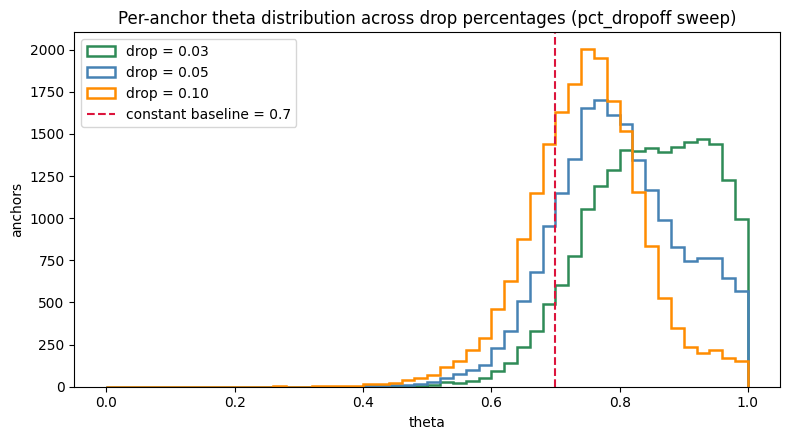

drop=0.03: theta mean/median = 0.845/0.852  stricter than 0.7: 18,552 (92.7%)
drop=0.05: theta mean/median = 0.798/0.793  stricter than 0.7: 16,873 (84.3%)
drop=0.10: theta mean/median = 0.748/0.751  stricter than 0.7: 14,438 (72.2%)


In [8]:
colors = {0.03: "seagreen", 0.05: "steelblue", 0.10: "darkorange"}

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0.0, 1.0, 51)
for v in DROP_PCT_VALUES:
    thetas = np.array([t["theta"] for t in results[v]["thresholds"].values()])
    ax.hist(thetas, bins=bins, histtype="step", linewidth=1.8,
            color=colors[v], label=f"drop = {v:.2f}")
ax.axvline(CONSTANT_THETA_BASELINE, color="crimson", linestyle="--", linewidth=1.5,
           label=f"constant baseline = {CONSTANT_THETA_BASELINE}")
ax.set_title("Per-anchor theta distribution across drop percentages (pct_dropoff sweep)")
ax.set_xlabel("theta"); ax.set_ylabel("anchors")
ax.legend()
plt.tight_layout(); plt.show()

for v in DROP_PCT_VALUES:
    thetas = np.array([t["theta"] for t in results[v]["thresholds"].values()])
    n_stricter = int((thetas > CONSTANT_THETA_BASELINE).sum())
    print(f"drop={v:.2f}: theta mean/median = {thetas.mean():.3f}/{np.median(thetas):.3f}  "
          f"stricter than {CONSTANT_THETA_BASELINE}: {n_stricter:,} "
          f"({100 * n_stricter / max(len(thetas), 1):.1f}%)")

## 8. Stress-test anchors — theta across all three values

The six stress-test anchors with their adaptive `theta` at each swept value shown side by side, next to the fixed 0.70 baseline. This is the clearest read on how much the drop percentage actually moves the per-anchor threshold for products we understand.

In [9]:
hdr = f"{'anchor':<30}" + "".join(f"{'drop ' + format(v, '.2f'):>12}" for v in DROP_PCT_VALUES)
hdr += f"{'fixed':>10}"
print(f"Adaptive theta by drop percentage vs constant baseline ({CONSTANT_THETA_BASELINE})")
print("=" * len(hdr))
print(hdr)
print("-" * len(hdr))
for pid, nm in STRESS_TEST_IDS.items():
    row = f"{nm:<30}"
    for v in DROP_PCT_VALUES:
        t = results[v]["thresholds"].get(pid)
        row += f"{'n/a':>12}" if t is None else f"{t['theta']:>12.3f}"
    row += f"{CONSTANT_THETA_BASELINE:>10.2f}"
    print(row)

Adaptive theta by drop percentage vs constant baseline (0.7)
anchor                           drop 0.03   drop 0.05   drop 0.10     fixed
----------------------------------------------------------------------------
Whole Milk                           0.984       0.808       0.808      0.70
Unsweetened Almond Milk              0.912       0.912       0.912      0.70
Organic Salted Butter                0.980       0.806       0.806      0.70
Vegan Butter                         0.853       0.750       0.750      0.70
Whole Milk Plain Yogurt              0.852       0.852       0.852      0.70
Coconut Yogurt                       0.872       0.872       0.872      0.70


## 9. Rank novelty — grouped by anchor, all three values consecutively

For each stress-test anchor we compute Step 1's own full ranking **once**, then show — for each swept value in turn — where that value's surfaced products sit in it (rank 1 = Step 1's nearest neighbour). Anything inside Step 1's top-10 is flagged "not new". Grouping by anchor first makes the effect of tightening the drop percentage directly visible per product.

In [10]:
# Precompute {value: {stress_pid: Counter(surfaced product -> times)}}.
surfaced_by_value = {v: {pid: Counter() for pid in STRESS_TEST_IDS} for v in DROP_PCT_VALUES}
for v in DROP_PCT_VALUES:
    for s in results[v]["kept"]:
        a = s["anchor_id"]
        if a in STRESS_TEST_IDS:
            for p in s["sentence"]:
                if p != a:
                    surfaced_by_value[v][a][p] += 1

print("Rank novelty: where do surfaced products sit in Step 1's own ranking?")
print("=" * 78)
for pid, nm in STRESS_TEST_IDS.items():
    print(f"\n{nm} ({pid})")
    if pid not in pid_to_idx:
        print("  — not in catalogue, skipped")
        continue
    sims = embeddings @ embeddings[pid_to_idx[pid]]      # computed ONCE, reused across values
    ranks = np.empty(len(sims), dtype=int)
    ranks[np.argsort(-sims)] = np.arange(len(sims))      # rank[idx]: 0 = anchor, 1 = #1 neighbour
    for v in DROP_PCT_VALUES:
        surfaced_here = surfaced_by_value[v][pid]
        print(f"  [drop = {v:.2f}]  ({len(surfaced_here)} distinct products surfaced)")
        if not surfaced_here:
            print("     (none)")
        for p, c in surfaced_here.most_common():
            r = int(ranks[pid_to_idx[p]])
            flag = "  <- inside Step 1's top-10, not new" if r <= 10 else ""
            print(f"     {c}x  {name(p):<45} rank={r:>6}  sim={sims[pid_to_idx[p]]:.3f}{flag}")

Rank novelty: where do surfaced products sit in Step 1's own ranking?

Whole Milk (4210)
  [drop = 0.03]  (0 distinct products surfaced)
     (none)
  [drop = 0.05]  (6 distinct products surfaced)
     8x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's top-10, not new
     3x  Organic Milk                                  rank=    22  sim=0.834
     3x  Fat Free Milk                                 rank=    29  sim=0.825
     2x  Chocolate Lowfat Milk                         rank=    31  sim=0.823
     1x  Chocolate Milk                                rank=     9  sim=0.869  <- inside Step 1's top-10, not new
     1x  Lowfat Milk                                   rank=    28  sim=0.827
  [drop = 0.10]  (6 distinct products surfaced)
     8x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's top-10, not new
     3x  Organic Milk                                  rank=    22  sim=0.834
     3x  Fat Free Milk 

## 10. Background popularity — grouped by anchor, all three values consecutively

How common each surfaced product is overall (a "substitute" in a huge fraction of baskets may just be popular). Read straight from `product_basket_freq.json`, grouped by anchor first with all three values shown consecutively.

In [11]:
print("Background popularity: how common is each surfaced product overall?")
print("=" * 78)
for pid, nm in STRESS_TEST_IDS.items():
    anchor_freq = product_basket_count.get(pid, 0)
    anchor_pct = 100 * anchor_freq / total_baskets if total_baskets else 0
    print(f"\n{nm} ({pid}) — anchor appears in "
          f"{anchor_freq:,} / {total_baskets:,} baskets ({anchor_pct:.1f}%)")
    for v in DROP_PCT_VALUES:
        surfaced_here = surfaced_by_value[v][pid]
        print(f"  [drop = {v:.2f}]")
        if not surfaced_here:
            print("     (none)")
        for p, c in surfaced_here.most_common(10):
            bg = product_basket_count.get(p, 0)
            bg_pct = 100 * bg / total_baskets if total_baskets else 0
            print(f"     {c}x  {name(p):<40} appears in "
                  f"{bg:>7,} / {total_baskets:,} baskets ({bg_pct:.1f}%)")

Background popularity: how common is each surfaced product overall?

Whole Milk (4210) — anchor appears in 11,103 / 1,000,000 baskets (1.1%)
  [drop = 0.03]
     (none)
  [drop = 0.05]
     8x  Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
     3x  Organic Milk                             appears in   8,660 / 1,000,000 baskets (0.9%)
     3x  Fat Free Milk                            appears in   9,189 / 1,000,000 baskets (0.9%)
     2x  Chocolate Lowfat Milk                    appears in   1,442 / 1,000,000 baskets (0.1%)
     1x  Chocolate Milk                           appears in     989 / 1,000,000 baskets (0.1%)
     1x  Lowfat Milk                              appears in   1,354 / 1,000,000 baskets (0.1%)
  [drop = 0.10]
     8x  Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
     3x  Organic Milk                             appears in   8,660 / 1,000,000 baskets (0.9%)
     3x  Fat Free Milk         